# 1.Impoting the library

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from IPython.display import Image,display

# 2.Defining the state

In [2]:
class bmi_state(TypedDict):
    weight_kg:float
    height_m:float
    bmi_cal:float
    category:str

# 3.Defining BMI Node

In [3]:
def bmi_node(state:bmi_state):
    weight=state["weight_kg"]
    height=state["height_m"]
    bmi_cal=weight/height**2
    return {"bmi_cal":bmi_cal}

# 4.Defining BMI Label

## Body Mass Index (BMI)

**Body Mass Index (BMI)** is a simple measure used to determine whether a person's weight is appropriate for their height.

### BMI Formula

BMI = Weight (kg)/Height (m)^2


---

## BMI Categories

| BMI Range | Category |
|-----------:|----------|
| Less than **18.5** | Underweight |
| **18.5 – 24.9** | Normal Weight |
| **25.0 – 29.9** | Overweight |
| **30.0 – 34.9** | Obesity (Class I) |
| **35.0 – 39.9** | Obesity (Class II) |
| **40.0 or above** | Obesity (Class III / Severe Obesity) |

---

## Example

**Weight:** 80 kg

**Height:** 1.65 m


BMI} = 80/1.65^2= 29.38


**Result:** **Overweight**

---

> **Note:** BMI is a screening tool and does not directly measure body fat. Factors such as muscle mass, age, sex, and ethnicity can influence its interpretation.

In [4]:
def bmi_label(state:bmi_state)->bmi_state:
    bmi=state["bmi_cal"]
    if bmi<18.5:
        state["category"]="Underweight"
    elif 18.5<=bmi<24.9:
        state["category"]="Normal Weight"
        
    elif 24.9<=bmi<29.9:
        state["category"]="Overweight"
        
    elif 29.9<=bmi<34.9:
        state["category"]="Obesity (Class1)"
        
    elif 34.9<=bmi<39.9:
        state["category"]="Obesity (Class2)"
        
    else:
        state["category"]="Obesity (Class3)"
        
    return state

# 5.Adding Node

In [5]:
graph=StateGraph(bmi_state)
graph.add_node("bmi_node",bmi_node)
graph.add_node("bmi_label",bmi_label)

# 6.Adding Edges

In [6]:
graph.add_edge(START,"bmi_node")
graph.add_edge("bmi_node","bmi_label")
graph.add_edge("bmi_label",END)

# 7.Compilation

In [7]:
workflow=graph.compile()

# 8.Defining Initial State

In [8]:
initial_state={
    "height_m":80,
    "weight_kg":1.65
}

# 9.Execute Workflow

In [9]:
result=workflow.invoke(initial_state)

# 10.Result

In [10]:
print(result)

{'weight_kg': 1.65, 'height_m': 80, 'bmi_cal': 0.0002578125, 'category': 'Underweight'}


# 11. Visualise the workflow

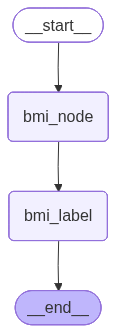

In [11]:
display(Image(workflow.get_graph().draw_mermaid_png()))